# Prepare explanation runner classes

In [1]:
# Cell 0: make sure `root/` is on PYTHONPATH so `import src.*` works
import sys, pathlib

# if this notebook is in root/scripts, then parent is root
root = pathlib.Path().resolve().parent
sys.path.insert(0, str(root))

print("Added to sys.path:", root)

Added to sys.path: /home/graph-winit


In [2]:
import pathlib
import torch
import numpy as np
import matplotlib.pyplot as plt
from omegaconf import OmegaConf
import time

from src.explanationrunner import ExplanationRunner
from src.dataloader import Mimic, SimulatedSwitch, SimulatedState
from src.dataloader import Mimic, MITECG, SimulatedSwitch, SimulatedState, SimulatedSpike, \
    WinITDataset, SimulatedData
from src.explainer.winitexplainers import WinITExplainer
from src.run import Params
import logging
logging.getLogger().setLevel(logging.INFO)


RuntimeError: module was compiled against NumPy C-API version 0x10 (NumPy 1.23) but the running NumPy has C-API version 0xf. Check the section C-API incompatibility at the Troubleshooting ImportError section at https://numpy.org/devdocs/user/troubleshooting-importerror.html#c-api-incompatibility for indications on how to solve this problem.

In [3]:


cfg = OmegaConf.load('../config/nb_3_eval.yaml')
argdict = OmegaConf.to_container(cfg, resolve=True)

# argdict = vars(parser.parse_args())
data = argdict['data']
explainers = argdict['explainer']
do_explain = argdict['do_explain']
eval_explain = argdict['eval_explain']
train_models = argdict['train']
train_gen = argdict['traingen']
result_file = argdict["resultfile"]
epoch_gen = argdict["epoch_gen"]

device = "cuda" if torch.cuda.is_available() else "cpu"

# parse the arg
params = Params(argdict)
dataset = params.datasets
model_args = params.model_args
model_train_args = params.model_train_args
all_explainer_dict = params.all_explainer_dict
out_path = params.outpath
ckpt_path = params.ckptpath
plot_path = params.plotpath
start_time = time.time()
log = logging.getLogger("Base")
for k, v in argdict.items():
    log.info(f"{k:15}: {v}")
first = True
save_failed = False


# overwrite a few things

base_path = pathlib.Path("/home/WinIT")  # adjust to your repo root


2025-09-11 18:22:57,902     INFO                      Base: data           : state
2025-09-11 18:22:57,903     INFO                      Base: delay          : 0
2025-09-11 18:22:57,904     INFO                      Base: explainer      : ['jimex']
2025-09-11 18:22:57,904     INFO                      Base: cv             : [0]
2025-09-11 18:22:57,905     INFO                      Base: testbs         : 16
2025-09-11 18:22:57,905     INFO                      Base: dataseed       : 1234
2025-09-11 18:22:57,906     INFO                      Base: datapath       : ../data
2025-09-11 18:22:57,906     INFO                      Base: explainerseed  : 2345
2025-09-11 18:22:57,907     INFO                      Base: outpath        : ../output_nb/
2025-09-11 18:22:57,907     INFO                      Base: ckptpath       : ../ckpt/
2025-09-11 18:22:57,907     INFO                      Base: plotpath       : ../plots/
2025-09-11 18:22:57,908     INFO                      Base: logpath        : 

In [4]:

dataset.load_data()  # populates dataset.train_loader, dataset.val_loader, etc.

# 2) Create the runner and either train or load a pretrained model
runner = ExplanationRunner(
    dataset=dataset,
    device=device,
    out_path=out_path,
    ckpt_path=ckpt_path,
    plot_path=plot_path
)

# If you do need to train the model:
if train_models:
    runner.init_model(**model_args)
    runner.train_model(**model_train_args, use_all_times=True)
else:
    # Load a saved checkpoint
    runner.init_model(**model_args)
    runner.load_model(use_all_times=True)

print("✔️  Dataset loaded and model ready. ")


2025-09-11 18:23:01,138     INFO         ExplanationRunner: Average Accuracy = 0.8854±0.0000
2025-09-11 18:23:01,142     INFO         ExplanationRunner: Average AUC = 0.9065±0.0000
2025-09-11 18:23:01,143     INFO         ExplanationRunner: Average AUPRC = 0.7652±0.0000
2025-09-11 18:23:01,143     INFO         ExplanationRunner: Model Accuracy on Tests = [0.8854].
2025-09-11 18:23:01,144     INFO         ExplanationRunner: Model AUC on Tests = [0.906477].
2025-09-11 18:23:01,145     INFO         ExplanationRunner: Model Precision on Tests = [0.769665].
2025-09-11 18:23:01,146     INFO         ExplanationRunner: Model Recall on Tests = [0.581675].
2025-09-11 18:23:01,147     INFO         ExplanationRunner: Model AUPRC on Tests = [0.765208].
2025-09-11 18:23:01,148     INFO         ExplanationRunner: Model F1 on Tests = [0.662594].


✔️  Dataset loaded and model ready. 


In [5]:
for explainer_name, explainer_dict_list in all_explainer_dict.items():
    for explainer_dict in explainer_dict_list:
        # generate feature importance
        runner.clean_up(clean_importance=True, clean_explainer=True, clean_model=False)
        runner.get_explainers(explainer_name, explainer_dict=explainer_dict)
        runner.set_model_for_explainer(set_eval=explainer_name != "fit")

        if do_explain:
            log.info(f"Running Explanations..."
                        f"Data={dataset.get_name()}, Explainer={explainer_name}, Dict={explainer_dict}")

            runner.load_generators()
            runner.run_attributes()
            runner.save_importance()
            importances = runner.importances
            log.info("Explanations done.")


In [6]:

test_iterator = iter(dataset.test_loader)
x_batch, y_batch = next(test_iterator)  # (batch_size, features, timesteps), (batch_size,)

x_batch = x_batch.to(device)
print(f"✔️  Fetched one batch: x_batch.shape = {x_batch.shape}, y_batch.shape = {y_batch.shape}")

exps = runner.explainers
cv = 0
explainer = exps[cv]

# Cell 0.7: Sanity‐check prediction on our sample
with torch.no_grad():
    p_test = explainer._model_predict(x_batch)
# print("Model output probabilities:", p_test.cpu().numpy())


✔️  Fetched one batch: x_batch.shape = torch.Size([16, 3, 200]), y_batch.shape = torch.Size([16, 200])


In [39]:
p_test

tensor([[5.80504239e-01, 4.19495761e-01],
        [3.95032726e-02, 9.60496724e-01],
        [2.78710350e-02, 9.72128987e-01],
        [9.82461646e-02, 9.01753843e-01],
        [3.91754359e-01, 6.08245611e-01],
        [2.33731549e-02, 9.76626873e-01],
        [7.06013262e-01, 2.93986738e-01],
        [8.01583707e-01, 1.98416293e-01],
        [1.69930141e-03, 9.98300672e-01],
        [2.86340015e-03, 9.97136593e-01],
        [8.07896256e-01, 1.92103744e-01],
        [2.49716011e-03, 9.97502863e-01],
        [6.00566924e-01, 3.99433076e-01],
        [4.20385115e-02, 9.57961500e-01],
        [6.76747710e-02, 9.32325244e-01],
        [6.66373610e-01, 3.33626390e-01],
        [8.51412565e-02, 9.14858758e-01],
        [9.89299178e-01, 1.07008219e-02],
        [5.98065741e-02, 9.40193415e-01],
        [1.35703191e-01, 8.64296794e-01],
        [2.21478403e-01, 7.78521597e-01],
        [2.27734752e-04, 9.99772251e-01],
        [7.68718943e-02, 9.23128128e-01],
        [5.49334809e-02, 9.4506651

# Ready for shapley interactions

In [7]:
# -------------------------
# interaction_study.py
# -------------------------
import math, random, itertools, numpy as np
from typing import Callable, Dict, List, Tuple, Iterable
import torch
import torch.nn.functional as F
from tqdm import tqdm

# ---------- Utilities ----------
def kl_divergence(p: torch.Tensor, q: torch.Tensor, eps: float = 1e-8) -> torch.Tensor:
    """
    KL(p||q) for discrete distributions per-sample; returns scalar mean.
    p, q: (B, C) or (C,) probabilities; we average over batch if present.
    """
    if p.dim()==1: p, q = p.unsqueeze(0), q.unsqueeze(0)
    p = p.clamp(min=eps)
    q = q.clamp(min=eps)
    kl = (p * (p.log() - q.log())).sum(dim=-1)
    return kl.mean()

def apply_mask(X: torch.Tensor, keep_set: set, baseline_fn: Callable[[torch.Tensor], torch.Tensor]) -> torch.Tensor:
    """
    X: (T, D) or (B, T, D). We treat last two dims as (T, D).
    keep_set: set of (t,d) indices to KEEP; others are filled with baseline.
    """
    if X.dim()==2:
        Xb = baseline_fn(X)
        M = torch.zeros_like(X, dtype=torch.bool)
        for t,d in keep_set:
            M[t, d] = True
        Y = torch.where(M, X, Xb)
        return Y
    elif X.dim()==3:
        B,T,D = X.shape
        Xb = baseline_fn(X)  # same shape
        M = torch.zeros((T,D), dtype=torch.bool, device=X.device)
        for t,d in keep_set:
            M[t, d] = True
        M = M.unsqueeze(0).expand(B,T,D)
        Y = torch.where(M, X, Xb)
        return Y
    else:
        raise ValueError("X must be (T,D) or (B,T,D)")

# ---------- Value function v(S) ----------
@torch.no_grad()
def coalition_value(
    X: torch.Tensor,
    keep_set: set,
    model_predict: Callable[[torch.Tensor], torch.Tensor],
    baseline_fn: Callable[[torch.Tensor], torch.Tensor],
) -> float:
    """
    v(S) = KL(f(X) || f(mask(X; U \ S))).
    model_predict: returns probability vector (C,) or (B,C)
    """
    p = model_predict(X)
    Xm = apply_mask(X, keep_set, baseline_fn)
    q = model_predict(Xm)
    return float(kl_divergence(p, q))

# ---------- Permutation helper ----------
def pred_set_from_permutation(pi: List[Tuple[int,int]], u, v) -> set:
    """
    Given a full permutation of U as a list of (t,d), return the set of indices that appear
    before both u and v.
    """
    idx = {pi[i]: i for i in range(len(pi))}
    iu, iv = idx[u], idx[v]
    cutoff = min(iu, iv)
    return set(pi[:cutoff])

# ---------- Shapley interaction estimator I_{u,v} ----------
@torch.no_grad()
def estimate_pair_interaction(
    X: torch.Tensor,
    u: Tuple[int,int],
    v: Tuple[int,int],
    U: List[Tuple[int,int]],
    K: int,
    model_predict: Callable[[torch.Tensor], torch.Tensor],
    baseline_fn: Callable[[torch.Tensor], torch.Tensor],
) -> float:
    """
    Monte-Carlo permutation estimator:
    I_{u,v} = E_pi [ v(T ∪ {u,v}) - v(T ∪ {u}) - v(T ∪ {v}) + v(T) ],
    where T = Pred_pi(u,v).
    """
    TUD = len(U)
    acc = 0.0
    for _ in range(K):
        pi = U.copy()
        random.shuffle(pi)
        T = pred_set_from_permutation(pi, u, v)

        val_T    = coalition_value(X, T,                model_predict, baseline_fn)
        val_Tu   = coalition_value(X, T | {u},          model_predict, baseline_fn)
        val_Tv   = coalition_value(X, T | {v},          model_predict, baseline_fn)
        val_Tuv  = coalition_value(X, T | {u, v},       model_predict, baseline_fn)

        acc += (val_Tuv - val_Tu - val_Tv + val_T)
    return acc / K

# ---------- Build interaction field H ----------
def build_interaction_field(
    X: torch.Tensor,
    T: int,
    D: int,
    K: int,
    model_predict: Callable[[torch.Tensor], torch.Tensor],
    baseline_fn: Callable[[torch.Tensor], torch.Tensor],
    tau_max: int = 5,
    cross_k: int = 3,
    seed: int = 0,
) -> Tuple[torch.Tensor, Dict[Tuple[Tuple[int,int],Tuple[int,int]], float]]:
    """
    Restrict pairs to: within-feature lags |tau| <= tau_max,
                       and same-time cross-feature top-k neighbors (by correlation heuristic).
    Returns:
      H: (T,D) tensor (>=0)
      pair_I: dict with signed I_{u,v} for inspected pairs
    """
    torch.manual_seed(seed); random.seed(seed); np.random.seed(seed)

    U = [(t,d) for t in range(T) for d in range(D)]
    pair_I = {}

    # simple cross-feature neighborhood via correlation at same time
    X_np = X.detach().cpu().numpy()
    if X.dim()==3: X_np = X_np.mean(axis=0)  # average batch if present
    # (T,D)
    # corr = np.corrcoef(X_np.T)  # D×D
    # cross_neighbors = {}
    # for d in range(D):
    #     idx = np.argsort(-np.abs(corr[d]))  # descending by |corr|
    #     idx = [j for j in idx if j!=d][:cross_k]
    #     cross_neighbors[d] = idx

    H = torch.zeros((T,D), dtype=torch.float32, device=X.device)

    # within-feature lag pairs

    for d in range(D):
        for t in tqdm(range(T), desc=f"d={d}", leave=False):
            u = (t,d)
            # lag neighbors
            for tau in range(-tau_max, tau_max+1):
                if tau==0: continue
                t2 = t+tau
                if 0<=t2<T:
                    v = (t2,d)
                    Iuv = estimate_pair_interaction(X, u, v, U, K, model_predict, baseline_fn)
                    pair_I[(u,v)] = Iuv
                    if Iuv > 0: H[t,d] += Iuv

    print('within H: same feature lag done')

    # same-time cross-feature neighbors


    for t in range(T):
        for d in tqdm(range(D), desc=f"t={t}", leave=False):
            u = (t,d)
            for d2 in range(D):
                if d2==d: continue
                v = (t,d2)
                Iuv = estimate_pair_interaction(X, u, v, U, K, model_predict, baseline_fn)
                pair_I[(u,v)] = Iuv
                if Iuv > 0: H[t,d] += Iuv


    print('within T: same time lag done')

    return H, pair_I

# ---------- Metrics ----------
def gini(x: np.ndarray) -> float:
    """Gini coefficient for nonnegative vector."""
    x = x.flatten()
    if np.allclose(x, 0): return 0.0
    x = np.sort(x)
    n = len(x)
    cum = np.cumsum(x)
    g = (n + 1 - 2*(cum / cum[-1]).sum() / n)
    return float(g)

def topk_iou(A: np.ndarray, B: np.ndarray, k: int) -> float:
    a_idx = np.argsort(A.ravel())[::-1][:k]
    b_idx = np.argsort(B.ravel())[::-1][:k]
    a_set, b_set = set(a_idx), set(b_idx)
    inter = len(a_set & b_set)
    union = len(a_set | b_set)
    return inter/union if union>0 else 1.0

def lag_profile(pair_I: Dict, T:int, D:int, max_tau:int=10):
    """
    Compute rho_d(tau) = median_t I_{(t,d),(t+tau,d)}; return arrays
    """
    taus = list(range(-max_tau, max_tau+1))
    rho = np.zeros((D, len(taus)))
    for d in range(D):
        for j,tau in enumerate(taus):
            vals = []
            for t in range(T):
                t2 = t + tau
                if 0<=t2<T and ((t,d),(t2,d)) in pair_I:
                    vals.append(pair_I[((t,d),(t2,d))])
            rho[d, j] = np.median(vals) if len(vals)>0 else 0.0
    return taus, rho

# ---------- Example hooks you must fill ----------
@torch.no_grad()
def example_model_predict(X: torch.Tensor) -> torch.Tensor:
    """
    Wraps your explainer._model_predict so that the interaction study
    can use the exact same prediction routine.
    Ensures output is probabilities (B,C) or (C,) if unbatched.
    """
    # if your model expects a batch, add a batch dim if needed
    was_2d = (X.dim() == 2)
    if was_2d:
        X = X.unsqueeze(0)  # -> (1,T,D)

    X = X.permute(0,2,1)
    probs = explainer._model_predict(X)   # should return (B,C)

    if was_2d:
        probs = probs.squeeze(0)          # -> (C,)
    return probs

# Example baseline: seasonal mean or zeros; here zeros
def zero_baseline(X: torch.Tensor) -> torch.Tensor:
    return torch.zeros_like(X)

# ---------- Runner: one study pass ----------
def run_interaction_study(
    X: torch.Tensor,
    K: int = 100,
    tau_max: int = 5,
    cross_k: int = 3,
    seed: int = 0,
    model_predict: Callable = example_model_predict,
    baseline_fn: Callable = zero_baseline,
):
    T, D = X.shape[-2], X.shape[-1]
    H, pair_I = build_interaction_field(
        X, T, D, K, model_predict, baseline_fn,
        tau_max=tau_max, cross_k=cross_k, seed=seed
    )
    print('interaction field built')
    H_cpu = H.detach().cpu().numpy()
    # Metrics
    H_gini = gini(H_cpu.clip(min=0))
    taus, rho = lag_profile(pair_I, T, D, max_tau=tau_max)
    return dict(H=H, pair_I=pair_I, H_gini=H_gini, taus=taus, rho=rho)

# ---------- Stability / sample-efficiency ----------
def stability_across_seeds(X, seeds=[0,1,2], **kwargs):
    Hs, rhos = [], []
    for s in seeds:
        out = run_interaction_study(X, seed=s, **kwargs)
        Hs.append(out['H'].detach().cpu().numpy())
        rhos.append(out['rho'])
    # Spearman between vec(H)s
    from scipy.stats import spearmanr
    S = len(Hs)
    corrs = []
    for i in range(S):
        for j in range(i+1,S):
            a,b = Hs[i].ravel(), Hs[j].ravel()
            corrs.append(spearmanr(a,b).correlation)
    # IoU@k curve
    ks = [50, 100, 200, 500]
    ious = {k:[] for k in ks}
    for i in range(S):
        for j in range(i+1,S):
            A, B = Hs[i], Hs[j]
            for k in ks:
                ious[k].append(topk_iou(A, B, k))
    iou_mean = {k: float(np.mean(v)) for k,v in ious.items()}
    return dict(spearman_mean=float(np.mean(corrs)), iou_mean=iou_mean)

def sample_efficiency_curve(X, Ks=[50,100,200,400], seed=0, **kwargs):
    # Compare to a high-K reference
    print('started estimating efficiency')
    ref = run_interaction_study(X, K=max(Ks)*2, seed=seed, **kwargs)
    H_ref = ref['H'].detach().cpu().numpy()
    out = []
    for K in Ks:
        print('k in ks:', K)
        r = run_interaction_study(X, K=K, seed=seed, **kwargs)
        H = r['H'].detach().cpu().numpy()
        corr = np.corrcoef(H.ravel(), H_ref.ravel())[0,1]
        varH = np.var(H)
        out.append(dict(K=K, corr_to_ref=float(corr), varH=float(varH), H_gini=float(r['H_gini'])))
    return out


import matplotlib.pyplot as plt

def show_H(H):
    Hn = H.detach().cpu().numpy()
    plt.imshow(Hn, aspect='auto')
    plt.title("Interaction Field H (synergy mass)")
    plt.xlabel("Feature d"); plt.ylabel("Time t")
    plt.colorbar(); plt.show()
    plt.show()
def show_lag_profiles(taus, rho):
    # rho: D × len(taus)
    med = np.median(rho, axis=0)
    q25 = np.percentile(rho, 25, axis=0)
    q75 = np.percentile(rho, 75, axis=0)
    plt.plot(taus, med, label='median across features')
    plt.fill_between(taus, q25, q75, alpha=0.2, label='IQR')
    plt.title("Lag interaction profile ρ_d(τ)")
    plt.xlabel("lag τ"); plt.ylabel("interaction (median)")
    plt.legend(); plt.show()
    plt.show()


In [ ]:

# X_demo = torch.randn(256, 8)  # (T,D) demo; replace with your data
# Or (B,T,D) if your predictor expects batching

test_iterator = iter(dataset.test_loader)
x_batch, y_batch = next(test_iterator)  # (batch_size, features, timesteps), (batch_size,)
x_batch = x_batch.permute(0, 2, 1).contiguous()
x_batch = x_batch.to(device)


X_demo = x_batch #torch.randn(4, 32, 4)

out = run_interaction_study(
    X_demo, K=10, tau_max=3, cross_k=3,
    model_predict=example_model_predict,  # replace with your f_theta
    baseline_fn=zero_baseline
)

d=2:  40%|████      | 80/200 [19:31<20:46, 10.39s/it]  

In [1]:
out

NameError: name 'out' is not defined

first call completed


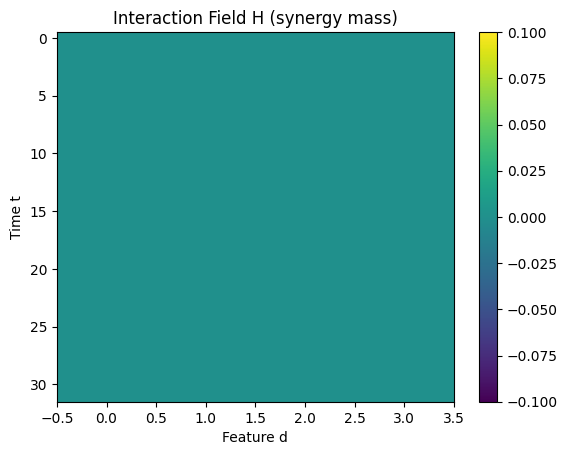

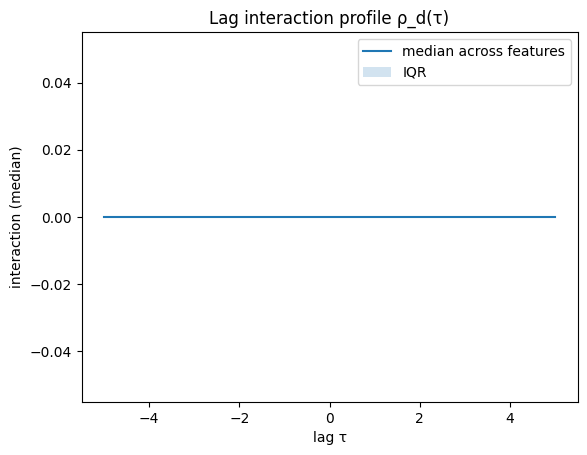

started estimating efficiency


KeyboardInterrupt: 

In [ ]:


print('first call completed')

show_H(out['H'])
show_lag_profiles(out['taus'], out['rho'])

# stab = stability_across_seeds(
#     X_demo, seeds=[0,1,2],
#     K=16, tau_max=5, cross_k=3,
#     model_predict=example_model_predict, baseline_fn=zero_baseline
# )
# print("Stability:", stab)

eff = sample_efficiency_curve(
    X_demo, Ks=[2,4,6,8,10], seed=0,
    tau_max=5, cross_k=3,
    model_predict=example_model_predict, baseline_fn=zero_baseline
)
print("Sample efficiency:", eff)
